# V4 social-signal prompt evaluation

This notebook compares the new v4 prompt runs against the v3 social-signal experiments on the same v3-clean evaluation rows.

Main metric: multilabel micro-F1 over the 36 factor labels.

Supporting metrics:
- `micro_precision`, `micro_recall`: pair-level factor quality.
- `any_relevant_f1`: whether the model detects that a news item has any relevant factor.
- `sample_f1_empty_correct`: per-news multilabel F1, with empty-empty counted as correct.
- per-factor precision/recall/F1 for the selected v4 run.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

ROOT = Path.cwd()
OUT = ROOT / "analysis_outputs"
DATASET_PATH = OUT / "v3_clean_broad_weak_dataset_1000.csv"
PROMPT_PATH = ROOT / "FINAL_v4_prompt_social_signal_high_recall_ru.md"

from analyzer.factors import FACTOR_CONFIG

FACTOR_KEYS = [item["key"] for item in FACTOR_CONFIG]
FACTOR_NAMES = {item["key"]: item["name"] for item in FACTOR_CONFIG}

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

## Prompt and dataset sanity

In [2]:
df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")
df["dataset_row_id"] = pd.to_numeric(df["dataset_row_id"], errors="raise").astype(int)
df = df.set_index("dataset_row_id", drop=False)

Y_all = pd.DataFrame(
    {
        key: pd.to_numeric(df[f"factor__{key}"], errors="coerce").fillna(0).astype(int).clip(0, 1)
        for key in FACTOR_KEYS
    },
    index=df.index,
)

prompt_text = PROMPT_PATH.read_text(encoding="utf-8")
prompt_overview = pd.DataFrame(
    [
        {"metric": "prompt_chars", "value": len(prompt_text)},
        {"metric": "dataset_rows", "value": len(df)},
        {"metric": "positive_factor_pairs", "value": int(Y_all.values.sum())},
        {"metric": "mean_labels_per_news", "value": round(float(Y_all.sum(axis=1).mean()), 3)},
        {"metric": "empty_news", "value": int((Y_all.sum(axis=1) == 0).sum())},
        {"metric": "factor_count", "value": len(FACTOR_KEYS)},
    ]
)
prompt_overview

,metric,value
0,prompt_chars,10623.000
1,dataset_rows,1000.000
2,positive_factor_pairs,2765.000
3,mean_labels_per_news,2.765
4,empty_news,33.000
5,factor_count,36.000


## Run discovery

In [3]:
def read_metrics(pattern: str, family: str) -> pd.DataFrame:
    rows = []
    for path in sorted(OUT.glob(pattern)):
        frame = pd.read_csv(path)
        frame["family"] = family
        frame["metrics_file"] = path.name
        frame["run_id"] = re.sub(r"^(v3|v4)_social_signal_experiment_metrics_", "", path.stem)
        rows.append(frame)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

metrics = pd.concat(
    [
        read_metrics("v3_social_signal_experiment_metrics_*.csv", "v3"),
        read_metrics("v4_social_signal_experiment_metrics_*.csv", "v4"),
    ],
    ignore_index=True,
)
metrics["is_search237"] = metrics["metrics_file"].str.contains("search237", regex=False)
metrics["is_pilot"] = metrics["metrics_file"].str.contains("pilot", case=False, regex=False)
metrics["sort_scope"] = np.select(
    [metrics["is_search237"], metrics["is_pilot"]],
    ["search237", "pilot"],
    default="other",
)
coverage = (
    metrics.groupby(["family", "metrics_file"], as_index=False)
    .agg(n_news=("n_news", "max"), best_micro_f1=("micro_f1", "max"), best_any_f1=("any_relevant_f1", "max"))
    .sort_values(["family", "n_news", "best_micro_f1"], ascending=[True, False, False])
)
coverage

,family,metrics_file,n_news,best_micro_f1,best_any_f1
5,v3,v3_social_signal_experiment_metrics_think_true_v3_b1_search237_think.csv,237,0.417559,0.976242
3,v3,v3_social_signal_experiment_metrics_think_false_v3_b1_search237.csv,237,0.401737,0.960526
4,v3,v3_social_signal_experiment_metrics_think_false_v4_b1_search237.csv,237,0.383260,0.941964
2,v3,v3_social_signal_experiment_metrics_think_false_v3_b1_pilot18.csv,18,0.285714,0.875000
0,v3,v3_social_signal_experiment_metrics_think_false.csv,18,0.156863,0.740741
1,v3,v3_social_signal_experiment_metrics_think_false_b1_pilot18.csv,18,0.156863,0.740741
9,v4,v4_social_signal_experiment_metrics_v4_prompt_think_false_compact_b1_search237.csv,237,0.394656,0.960352
6,v4,v4_social_signal_experiment_metrics_v4_prompt_think_false_b1_pilot18.csv,18,0.456140,0.941176
7,v4,v4_social_signal_experiment_metrics_v4_prompt_think_false_compact_b1_ctx16k_pilot18.csv,18,0.327273,0.909091
8,v4,v4_social_signal_experiment_metrics_v4_prompt_think_false_compact_b1_ctx16k_text6k_pilot18.csv,18,0.296296,0.875000


## Scoreboard

In [4]:
scoreboard = (
    metrics.sort_values(["n_news", "micro_f1", "micro_recall"], ascending=[False, False, False])
    .groupby(["family", "metrics_file"], as_index=False)
    .head(3)
    [[
        "family",
        "metrics_file",
        "variant",
        "threshold",
        "n_news",
        "gold_positive_pairs",
        "pred_positive_pairs",
        "pred_mean_labels",
        "micro_precision",
        "micro_recall",
        "micro_f1",
        "macro_f1_supported",
        "sample_f1_empty_correct",
        "any_relevant_f1",
        "false_relevant_news",
        "missed_all_relevant_news",
    ]]
    .sort_values(["n_news", "micro_f1"], ascending=[False, False])
)
scoreboard.round(4)

,family,metrics_file,variant,threshold,n_news,gold_positive_pairs,pred_positive_pairs,pred_mean_labels,micro_precision,micro_recall,micro_f1,macro_f1_supported,sample_f1_empty_correct,any_relevant_f1,false_relevant_news,missed_all_relevant_news
70,v3,v3_social_signal_experiment_metrics_think_true_v3_b1_search237_think.csv,social_signal_v3,default,237,656,278,1.1730,0.7014,0.2973,0.4176,0.2322,0.4037,0.9762,10,1
71,v3,v3_social_signal_experiment_metrics_think_true_v3_b1_search237_think.csv,social_signal_v3,0.05,237,656,278,1.1730,0.7014,0.2973,0.4176,0.2322,0.4037,0.9762,10,1
72,v3,v3_social_signal_experiment_metrics_think_true_v3_b1_search237_think.csv,social_signal_v3,0.10,237,656,278,1.1730,0.7014,0.2973,0.4176,0.2322,0.4037,0.9762,10,1
50,v3,v3_social_signal_experiment_metrics_think_false_v3_b1_search237.csv,social_signal_v3,0.05,237,656,265,1.1181,0.6981,0.2820,0.4017,0.1870,0.4018,0.9605,10,8
51,v3,v3_social_signal_experiment_metrics_think_false_v3_b1_search237.csv,social_signal_v3,0.10,237,656,265,1.1181,0.6981,0.2820,0.4017,0.1870,0.4018,0.9605,10,8
52,v3,v3_social_signal_experiment_metrics_think_false_v3_b1_search237.csv,social_signal_v3,default,237,656,263,1.1097,0.6996,0.2805,0.4004,0.1870,0.4008,0.9605,10,8
110,v4,v4_social_signal_experiment_metrics_v4_prompt_think_false_compact_b1_search237.csv,v4_prompt,default,237,656,317,1.3376,0.6057,0.2927,0.3947,0.3089,0.3651,0.9581,9,10
111,v4,v4_social_signal_experiment_metrics_v4_prompt_think_false_compact_b1_search237.csv,v4_prompt,0.20,237,656,317,1.3376,0.6057,0.2927,0.3947,0.3089,0.3651,0.9581,9,10
112,v4,v4_social_signal_experiment_metrics_v4_prompt_think_false_compact_b1_search237.csv,v4_prompt,0.30,237,656,317,1.3376,0.6057,0.2927,0.3947,0.3089,0.3651,0.9581,9,10
60,v3,v3_social_signal_experiment_metrics_think_false_v4_b1_search237.csv,social_signal_v4,default,237,656,252,1.0633,0.6905,0.2652,0.3833,0.1736,0.3690,0.9420,10,16


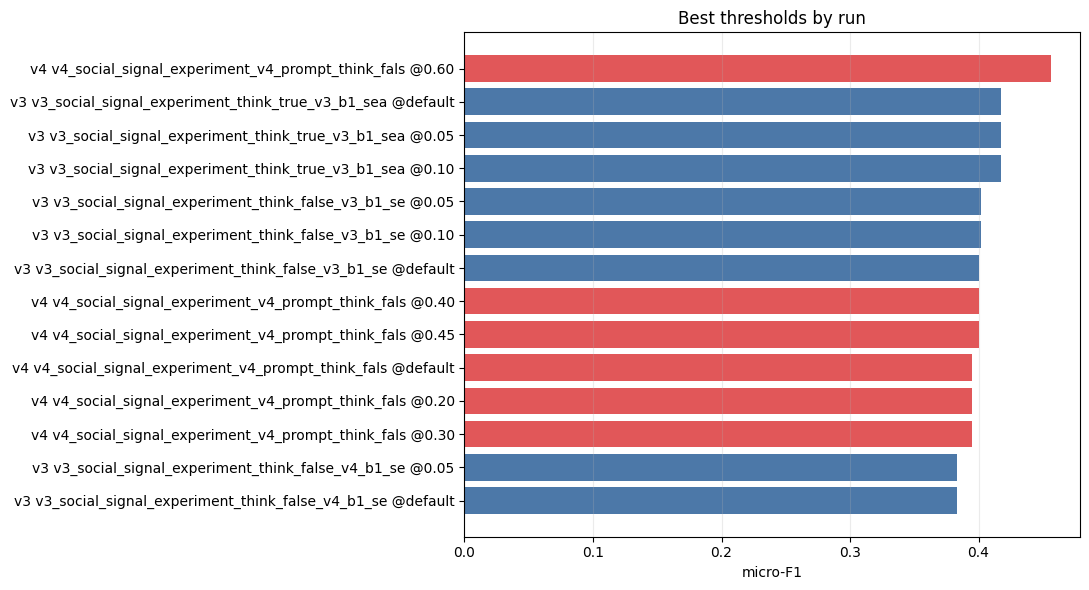

In [5]:
plot_df = scoreboard.copy()
plot_df["label"] = plot_df["family"] + " " + plot_df["metrics_file"].str.replace("_metrics_", "_", regex=False).str[:48] + " @" + plot_df["threshold"].astype(str)
plot_df = plot_df.sort_values("micro_f1", ascending=True).tail(14)

fig, ax = plt.subplots(figsize=(11, 6))
colors = np.where(plot_df["family"].eq("v4"), "#e15759", "#4c78a8")
ax.barh(plot_df["label"], plot_df["micro_f1"], color=colors)
ax.set_title("Best thresholds by run")
ax.set_xlabel("micro-F1")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Select best v4 prediction file

In [6]:
v4_metrics = metrics[metrics["family"].eq("v4")].copy()
if v4_metrics.empty:
    raise RuntimeError("No v4 metrics found")

prefer = v4_metrics[v4_metrics["is_search237"]].copy()
if prefer.empty:
    prefer = v4_metrics.copy()

best_v4 = prefer.sort_values(["micro_f1", "micro_recall"], ascending=False).iloc[0].to_dict()
suffix = best_v4["metrics_file"].replace("v4_social_signal_experiment_metrics_", "").replace(".csv", "")
pred_path = OUT / f"v4_social_signal_experiment_{suffix}.csv"
if not pred_path.exists():
    pred_path = sorted(OUT.glob(f"v4_social_signal_experiment_{suffix}.partial.csv"))[-1]
threshold = None if best_v4["threshold"] == "default" else float(best_v4["threshold"])

best_v4_summary = pd.DataFrame([{
    "metrics_file": best_v4["metrics_file"],
    "prediction_file": pred_path.name,
    "threshold": best_v4["threshold"],
    "n_news": best_v4["n_news"],
    "micro_precision": best_v4["micro_precision"],
    "micro_recall": best_v4["micro_recall"],
    "micro_f1": best_v4["micro_f1"],
    "any_relevant_f1": best_v4["any_relevant_f1"],
}])
best_v4_summary.round(4)

,metrics_file,prediction_file,threshold,n_news,micro_precision,micro_recall,micro_f1,any_relevant_f1
0,v4_social_signal_experiment_metrics_v4_prompt_think_false_compact_b1_search237.csv,v4_social_signal_experiment_v4_prompt_think_false_compact_b1_search237.csv,default,237,0.6057,0.2927,0.3947,0.9581


## Per-factor diagnostics for selected v4 run

In [7]:
pred = pd.read_csv(pred_path)
eval_ids = sorted(pred["dataset_row_id"].astype(int).unique().tolist())
y_true = Y_all.reindex(index=eval_ids, columns=FACTOR_KEYS).fillna(0).astype(int)
scores = (
    pred.pivot(index="dataset_row_id", columns="factor_key", values="relevance")
    .reindex(index=eval_ids, columns=FACTOR_KEYS)
    .fillna(0.0)
)
if threshold is None:
    y_pred = (
        pred.pivot(index="dataset_row_id", columns="factor_key", values="is_relevant")
        .reindex(index=eval_ids, columns=FACTOR_KEYS)
        .fillna(False)
        .astype(int)
    )
else:
    y_pred = (scores >= threshold).astype(int)

per_factor_rows = []
for key in FACTOR_KEYS:
    p, r, f1, _ = precision_recall_fscore_support(y_true[key], y_pred[key], average="binary", zero_division=0)
    per_factor_rows.append(
        {
            "factor_key": key,
            "factor_name": FACTOR_NAMES[key],
            "support": int(y_true[key].sum()),
            "predicted": int(y_pred[key].sum()),
            "precision": float(p),
            "recall": float(r),
            "f1": float(f1),
        }
    )
per_factor = pd.DataFrame(per_factor_rows).sort_values(["support", "f1"], ascending=[False, False])
display(per_factor.head(24).round(4))
display(per_factor[per_factor["support"].gt(0)].sort_values("f1").head(16).round(4))

,factor_key,factor_name,support,predicted,precision,recall,f1
29,industrial_production_index,Индексы промышленного производства,130,75,0.8000,0.4615,0.5854
30,enterprises_count,Число предприятий и организаций,100,19,0.7895,0.1500,0.2521
31,crime_count,Количество преступлений,73,32,0.8438,0.3699,0.5143
26,consumer_price_index,Индексы потребительских цен,64,21,0.9048,0.2969,0.4471
8,life_expectancy,Ожидаемая продолжительность жизни,51,8,0.8750,0.1373,0.2373
12,real_income_index,Реальные денежные доходы населения,47,5,0.6000,0.0638,0.1154
11,per_capita_income,Среднедушевые денежные доходы населения,40,2,1.0000,0.0500,0.0952
34,mortality_rate,Коэффициент смертности на 1000 человек,26,17,0.7647,0.5000,0.6047
16,hospitals,Число больничных организаций,20,10,1.0000,0.5000,0.6667
32,air_pollution,Выбросы загрязняющих веществ в атмосферный воздух,17,12,0.3333,0.2353,0.2759


,factor_key,factor_name,support,predicted,precision,recall,f1
13,unemployment_rate,Уровень безработицы,6,1,0.0000,0.0000,0.0000
2,marriage_rate,Число зарегистрированных браков на 1000 населения,1,0,0.0000,0.0000,0.0000
9,male_population,Число мужчин,2,2,0.0000,0.0000,0.0000
4,international_outflow,Число выбывших из страны,2,26,0.0000,0.0000,0.0000
20,preschool_coverage,Охват детей до 6 лет дошкольным образованием,3,0,0.0000,0.0000,0.0000
5,internal_arrivals,Число прибытий внутри региона,3,3,0.0000,0.0000,0.0000
14,living_wage,Величина прожиточного минимума на душу населения,4,0,0.0000,0.0000,0.0000
0,population_size,Численность населения,5,0,0.0000,0.0000,0.0000
7,infant_mortality,Коэффициент младенческой смертности,1,0,0.0000,0.0000,0.0000
17,outpatient_clinics,Число амбулаторно-поликлинических организаций,1,3,0.0000,0.0000,0.0000


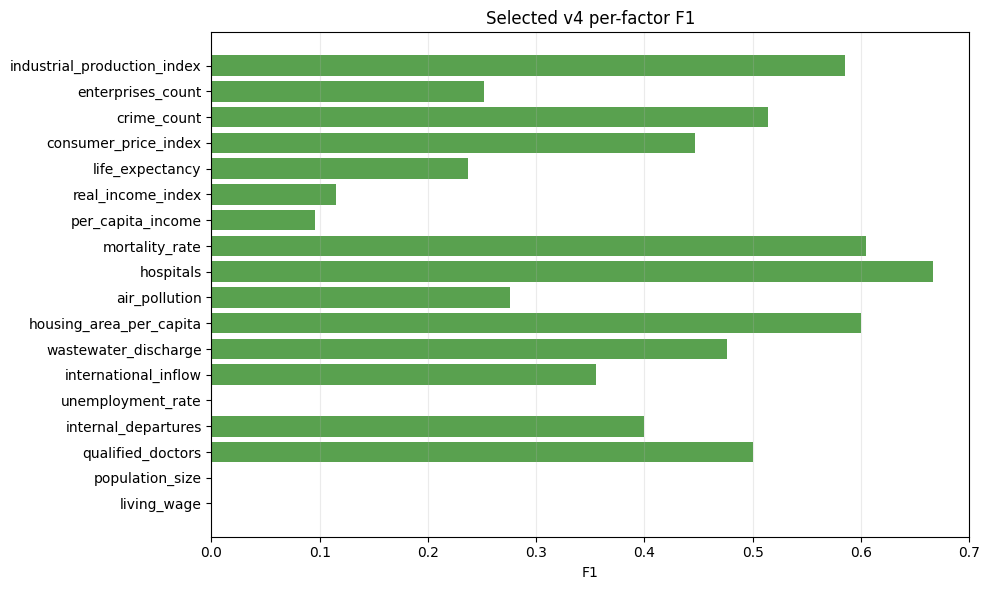

In [8]:
top = per_factor[per_factor["support"].gt(0)].sort_values("support", ascending=False).head(18).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top["factor_key"], top["f1"], color="#59a14f")
ax.set_title("Selected v4 per-factor F1")
ax.set_xlabel("F1")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Strength breakdown

In [9]:
strength_rows = []
for key in FACTOR_KEYS:
    strength_col = f"strength__{key}"
    if strength_col not in df.columns:
        continue
    for strength in ["direct", "context", "weak"]:
        mask = y_true[key].eq(1) & df.reindex(eval_ids)[strength_col].fillna("").astype(str).str.lower().eq(strength)
        support = int(mask.sum())
        if support == 0:
            continue
        hits = int((y_pred.loc[mask.index[mask], key] == 1).sum())
        strength_rows.append({"strength": strength, "factor_key": key, "support": support, "hits": hits, "recall": hits / support})
strength_report = pd.DataFrame(strength_rows)
if not strength_report.empty:
    display(strength_report.groupby("strength", as_index=False).agg(support=("support", "sum"), hits=("hits", "sum")).assign(recall=lambda x: x["hits"] / x["support"]).round(4))
    display(strength_report.sort_values(["strength", "support"], ascending=[True, False]).head(30).round(4))
else:
    print("No strength columns available")

,strength,support,hits,recall
0,context,259,64,0.2471
1,direct,243,99,0.4074
2,weak,154,29,0.1883


,strength,factor_key,support,hits,recall
41,context,industrial_production_index,58,25,0.4310
19,context,real_income_index,46,3,0.0652
13,context,life_expectancy,42,4,0.0952
44,context,enterprises_count,17,1,0.0588
37,context,consumer_price_index,16,6,0.3750
56,context,mortality_rate,14,3,0.2143
27,context,hospitals,13,5,0.3846
35,context,housing_area_per_capita,13,9,0.6923
17,context,per_capita_income,11,0,0.0000
53,context,wastewater_discharge,5,1,0.2000


## Problem examples

In [10]:
true_sets = {idx: set(y_true.columns[y_true.loc[idx].eq(1)]) for idx in y_true.index}
pred_sets = {idx: set(y_pred.columns[y_pred.loc[idx].eq(1)]) for idx in y_pred.index}
problem_rows = []
for idx in eval_ids:
    gold = true_sets[idx]
    pred_set = pred_sets[idx]
    fp = sorted(pred_set - gold)
    fn = sorted(gold - pred_set)
    if fp or fn:
        problem_rows.append(
            {
                "dataset_row_id": idx,
                "title": df.loc[idx, "title"],
                "gold": ", ".join(sorted(gold)),
                "pred": ", ".join(sorted(pred_set)),
                "fp": ", ".join(fp),
                "fn": ", ".join(fn),
                "n_fp": len(fp),
                "n_fn": len(fn),
            }
        )
problems = pd.DataFrame(problem_rows).sort_values(["n_fn", "n_fp"], ascending=False)
problems.head(30)

,dataset_row_id,title,gold,pred,fp,fn,n_fp,n_fn
90,383,"Нефть ускорила рост, Brent подорожала до $65,72 за баррель","air_pollution, consumer_price_index, enterprises_count, industrial_production_index, life_expectancy, real_income_index",,,"air_pollution, consumer_price_index, enterprises_count, industrial_production_index, life_expectancy, real_income_index",0,6
91,396,ФАС выявила сговор на торгах по поставке жизненно важных лекарств,"consumer_price_index, crime_count, enterprises_count, hospitals, industrial_production_index, life_expectancy, real_income_index",consumer_price_index,,"crime_count, enterprises_count, hospitals, industrial_production_index, life_expectancy, real_income_index",0,6
142,654,Правительство сохранило статус государственных научных центров за 43 организациями,"consumer_price_index, enterprises_count, hospitals, industrial_production_index, per_capita_income, qualified_doctors, real_income_index",qualified_doctors,,"consumer_price_index, enterprises_count, hospitals, industrial_production_index, per_capita_income, real_income_index",0,6
46,199,Потери бюджета из-за нелегального табака оценены в 150 млрд рублей в год,"consumer_price_index, crime_count, enterprises_count, housing_area_per_capita, per_capita_income, real_income_index","crime_count, industrial_production_index",industrial_production_index,"consumer_price_index, enterprises_count, housing_area_per_capita, per_capita_income, real_income_index",1,5
105,466,"Фондовые рынки Европы выросли вслед за акциями оборонных компаний, Stoxx Europe 600 обновил рекорд","air_pollution, consumer_price_index, crime_count, enterprises_count, real_income_index",industrial_production_index,industrial_production_index,"air_pollution, consumer_price_index, crime_count, enterprises_count, real_income_index",1,5
207,946,"Суд запретил экс-предправления московского банка ""Легион"" Сокеркину выезжать из РФ","crime_count, enterprises_count, industrial_production_index, per_capita_income, real_income_index",international_outflow,international_outflow,"crime_count, enterprises_count, industrial_production_index, per_capita_income, real_income_index",1,5
53,247,В I чтении принят проект об увеличении сроков геологоразведки для двух районов ХМАО,"consumer_price_index, enterprises_count, industrial_production_index, per_capita_income, population_size, real_income_index",industrial_production_index,,"consumer_price_index, enterprises_count, per_capita_income, population_size, real_income_index",0,5
72,329,"Мужчине, пытавшемуся отравить 70 летчиков РФ, ужесточили приговор до пожизненного","consumer_price_index, crime_count, industrial_production_index, life_expectancy, male_population, mortality_rate",crime_count,,"consumer_price_index, industrial_production_index, life_expectancy, male_population, mortality_rate",0,5
1,9,В посольстве РФ рассказали о планах Британии отказаться от российского урана к 2028 году,"air_pollution, enterprises_count, industrial_production_index, per_capita_income","international_inflow, international_outflow","international_inflow, international_outflow","air_pollution, enterprises_count, industrial_production_index, per_capita_income",2,4
14,65,Жители двух белгородских сел остались без света после атаки дронов ВСУ,"crime_count, industrial_production_index, life_expectancy, mortality_rate","air_pollution, housing_area_per_capita","air_pollution, housing_area_per_capita","crime_count, industrial_production_index, life_expectancy, mortality_rate",2,4


## Raw v4 false-positive snippets

In [11]:
fp_rows = []
pred_positive = pred[pred["dataset_row_id"].isin(eval_ids)].copy()
if threshold is None:
    pred_positive = pred_positive[pred_positive["is_relevant"].astype(bool)]
else:
    pred_positive = pred_positive[pred_positive["relevance"].astype(float).ge(threshold)]
for _, row in pred_positive.iterrows():
    idx = int(row["dataset_row_id"])
    key = row["factor_key"]
    if key not in true_sets[idx]:
        fp_rows.append(
            {
                "dataset_row_id": idx,
                "factor_key": key,
                "title": df.loc[idx, "title"],
                "relevance": row["relevance"],
                "evidence": row.get("evidence", ""),
                "reason": row.get("reason", ""),
            }
        )
fp_detail = pd.DataFrame(fp_rows).sort_values(["factor_key", "relevance"], ascending=[True, False])
fp_detail.head(40)

,dataset_row_id,factor_key,title,relevance,evidence,reason
69,560,air_pollution,"Военные РФ сообщили, что ВСУ ночью атаковали энергообъект на Кубани, обеспечивающий перевалку нефти в КТК",0.88,возгоранием на площади 1700 кв. м,Пожар на объекте привел к загрязнению воздуха
11,65,air_pollution,Жители двух белгородских сел остались без света после атаки дронов ВСУ,0.85,временно отсутствует электроснабжение,отсутствие электроснабжения связано с инфраструктурным ущербом
51,377,air_pollution,Три человека погибли от отравления угарным газом в Дагестане,0.85,отравление угарным газом,Угарный газ является загрязнителем воздуха
21,96,air_pollution,Сложная погода прогнозируется в регионах Дальнего Востока,0.55,"прогнозируется снег, метель и сильный ветер",прогноз сильного ветра и метели связан с погодными условиями
38,273,air_pollution,КТК сообщил о повреждении выносного причала N2 в результате террористической атаки,0.55,"Осуществляется экологический мониторинг, действует план ликвидации аварийных разливов нефти",Мониторинг и план ликвидации разливов нефти связаны с экологией
10,57,air_pollution,"Резкое понижение температуры произойдет в регионах Поволжья, Урала и запада Сибири",0.30,понижение температуры,Изменение температуры может косвенно влиять на экологические условия
68,558,air_pollution,Ведется опрос водителя фуры после атаки дронов в Иркутской области,0.30,беспилотной опасностью,связь с потенциальным экологическим риском от дронов
105,809,air_pollution,ЛЭП и здание предприятия повреждены атаками ВСУ в Белгородской области,0.30,"повренена линия электропередачи, отсутствует электроснабжение",отключение электроснабжения может косвенно влиять на экологические показатели
46,343,childcare_allowance,"Семейную налоговую выплату в 2026 г. получат 7,3 млн работающих родителей двух и более детей",0.60,воспитываются около 11 млн детей,"упоминание о количестве детей, связанное с поддержкой"
2,17,childcare_allowance,Работающие россияне смогут получить налоговый вычет за оплату спортивных занятий родителям,0.55,получать налоговый вычет за оплату спортивных занятий родителям,"Вычет касается расходов на родителей, что косвенно связано с поддержкой семьи."


## Working notes

Use this notebook as the v4 prompt dashboard:
1. Compare `v4` versus `v3` on the same `search237` rows when the full run is present.
2. Check whether higher context and longer article text helped; pilot runs are intentionally kept in the scoreboard.
3. Use `Problem examples` and `Raw v4 false-positive snippets` to revise the prompt or add deterministic post-filters.